In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from scipy.linalg import null_space
from scipy.linalg import solve as linsolve
from scipy.linalg import svd
from scipy.linalg import eig as eigenvalues
from utils import *
rc('text', usetex=True)
rc('font', family='sans-serif', serif=['Helvetica'], size=18)

## Example: 3-level Rubidium atom #

In [21]:
def HR(Delta, Omega):
    """3-level Rubidium Hamiltonian"""
    Omega1 = Omega
    Omega2 = Omega
    Delta1 = Delta / 10
    Delta2 = Delta
    H = np.array([
        [0, 0, Omega1 / 2],
        [0, Delta1, Omega2 / 2],
        [Omega1 / 2, Omega2 / 2, Delta2]
    ], dtype=complex)
    return H


def LDiss1(r):
    """Dissipator 1 for Rubidium"""
    def func(gamma_d):
        L = gamma_d * np.array([[0, 1, 0], [0, 0, 0], [0, 0, 0]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def LDiss2(r):
    """Dissipator 2 for Rubidium"""
    def func(gamma_d):
        L = gamma_d * np.array([[0, 0, 1], [0, 0, 0], [0, 0, 0]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def LD1(r):
    """Dephasing dissipator 1 for Rubidium"""
    def func(gamma_phi):
        L = gamma_phi * np.array([[0, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def LD2(r):
    """Dephasing dissipator 2 for Rubidium"""
    def func(gamma_phi):
        L = gamma_phi * np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def diss(r):
    """Total dissipator for Rubidium system"""
    def func(Delta, Omega):
        gamma_d = 2 * np.pi * 6.1
        gamma_phi = 0.0
        return (LDiss1(r)(gamma_d) + 
                LDiss2(r)(gamma_d) + 
                LD1(r)(gamma_phi) + 
                LD2(r)(gamma_phi))
    return func

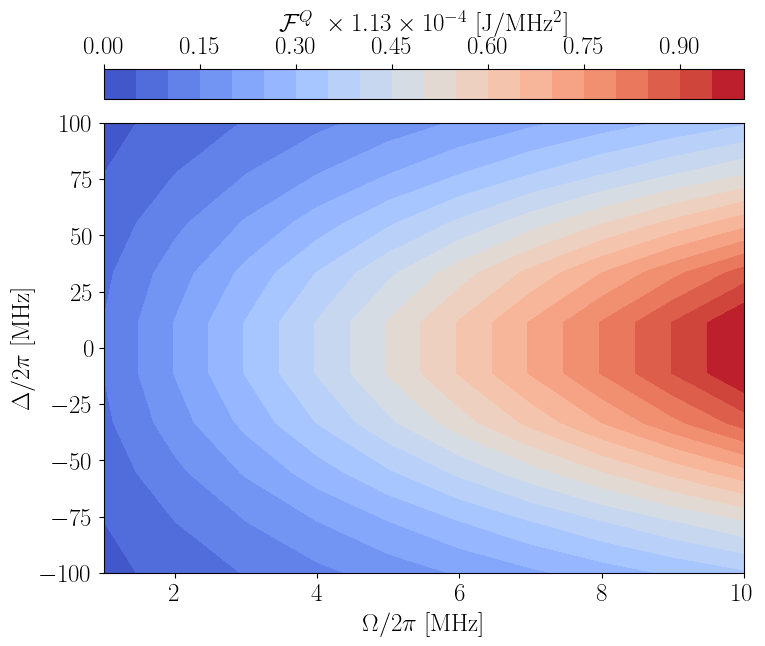

Computing Liouvillian Gap for 3x3 system...
Liouvillian gap between 7.35e+02 and 7.36e+02.


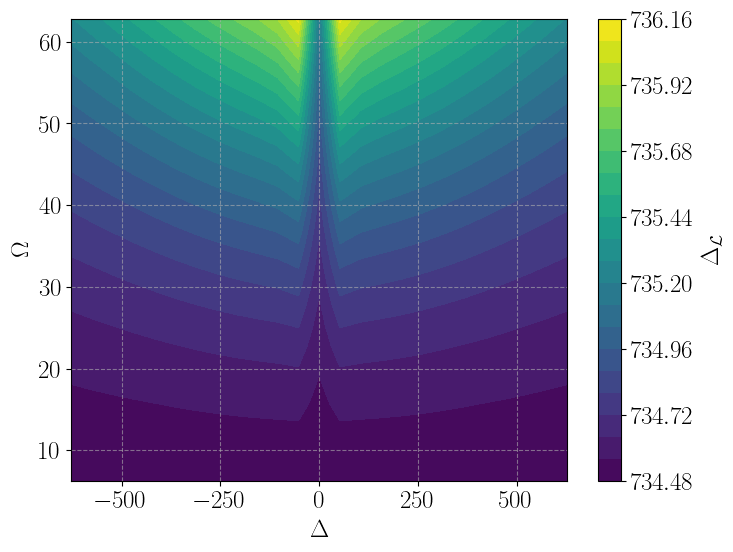

Starting cycle integration for d=3 system...
--- Results ---
Geometric Heat: 3.1667239676339647
Dissipated Heat: 5.671833067101215e-06
Net: 3.166729639467032
Temperature change over the cycle: 2.4188217106636794e-11 K


In [22]:
H1 = HR
range_Delta = [r'$\Delta$', -2 * np.pi * 100, 2 * np.pi * 100] # 2π × [-100, 100] MHz
range_Omega = [r'$\Omega$', 2 * np.pi, 2 * np.pi * 10] # 2π × [1, 10] MHz

p1_grid, p2_grid, curvature_data, max_val = old_heat_curvature(
    H1, H1, diss,
    ranges=[range_Delta, range_Omega],
    points=10
)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p2_grid / (2 * np.pi), p1_grid / (2 * np.pi), np.transpose(curvature_data), levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal', label=rf'$\mathcal{{F}}^{{Q}} \; \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/MHz^2]}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\Omega / 2 \pi \; \mathrm{[MHz]}$')
ax.set_ylabel(r'$\Delta / 2 \pi \; \mathrm{[MHz]}$')
plt.savefig('3lvl_Rb.pdf', bbox_inches='tight')
plt.show()

# Liouvillian Gap Example
liouvillian_gap(
    H1,
    diss,
    params=[r'$\Delta$', r'$\Omega$'],
    ranges=[range_Delta,range_Omega],
    points=25
)

# Reversible and Dissipative Heat Example
# Cycle path goes over the whole parameter range
q_geo, q_diss = compute_cycle_heats(
    H1,
    H1,
    diss,
    p_min=[range_Delta[1], range_Omega[1]],
    p_max=[range_Delta[2], range_Omega[2]],
    tau= 2* np.pi,
    points=100
)

kB = 1.380649e-23  # Boltzmann constant in J/K
hbar = 1.0545718e-34  # Reduced Planck constant in J*s
print("Temperature change over the cycle:", (q_geo + q_diss) * hbar / kB, "K")

## Example: Motion-TLS Coupled System ##

In [16]:
N_mot = 4

def H_motion_tls(delta_0, omega_rabi):
    """
    Motion-TLS Hamiltonian.
    omega_rf: RF frequency (variable parameter 1)
    omega_rabi: Rabi frequency (variable parameter 2)
    """
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()
    
    # Physical constants (using higher precision)
    x0 = np.longdouble(1e-5) # 0-10 \mu m
    omega_mot = np.longdouble(2 * np.pi * 500) # 2 pi 50-500 Hz
    mu_B = np.longdouble(9.27e-24) #  J/T
    gF = np.longdouble(0.5)
    B0 = np.longdouble(1e-3) # T
    dB = np.longdouble(10.0) # 1000 G/cm = 10 T/m
    hbar = np.longdouble(1.05e-34) # J s
    m = np.longdouble(1.44e-25) # kg
    
    # Oscillator length scale
    x_ho = np.sqrt(hbar / (np.longdouble(2) * m * omega_mot))
    eta = gF * mu_B * x_ho * dB / hbar
    # delta_0 = omega_rf - gF * mu_B * B0 / hbar
    
    # Hamiltonian components
    H_mot = omega_mot * (np.kron(sigma0, adag @ a) - x0 / x_ho * np.kron(sigma0, adag + a))
    H_spin = np.longdouble(0.5) * np.kron(delta_0 * sigma3 + omega_rabi * sigma1, np.eye(N_mot))
    H_coup = np.kron(sigma3, -0.5 * eta * (adag + a))

    return H_mot + H_spin + H_coup

def H_motion_tls_ref(delta_0, omega_rabi):
    """Reference Hamiltonian for Motion-TLS (photon number operator)"""
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()

    hbar = np.longdouble(1.05e-34) # J s
    m = np.longdouble(1.44e-25) # kg
    omega_mot = np.longdouble(2 * np.pi * 500) # 2 pi 50-500 Hz
    x0 = np.longdouble(1e-5) # 0-10 \mu m
    x_ho = np.sqrt(hbar / (np.longdouble(2) * m * omega_mot))

    H_mot = omega_mot * (np.kron(sigma0, adag @ a) - x0 / x_ho * np.kron(sigma0, adag + a))
    return H_mot


def diss_motion_tls(r):
    """Dissipator for Motion-TLS system"""
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()
    
    def func(omega_rf, omega_rabi):

        gamma_up = np.longdouble(1e5) # Hz
        #gamma_phi = np.longdouble(100.0) # Hz
        gamma_m = np.longdouble(50.0) # Hz
        #n_th = np.longdouble(1000) # thermal photon number

        L_up = np.sqrt(gamma_up) * np.kron(sigma_up, np.eye(N_mot))
        #L_phi = np.sqrt(gamma_phi / np.longdouble(2)) * np.kron(sigma3, np.eye(N_mot))
        #L_cool = np.sqrt(gamma_m * (n_th + np.longdouble(1))) * np.kron(np.eye(2), a)
        #L_heat = np.sqrt(gamma_m * n_th) * np.kron(np.eye(2), adag)
        L_mot = np.sqrt(gamma_m) * np.kron(np.eye(2), a + adag)
        
        return (lindblad_dissipator(L_up, r) +
                lindblad_dissipator(L_mot, r) )
        
    return func


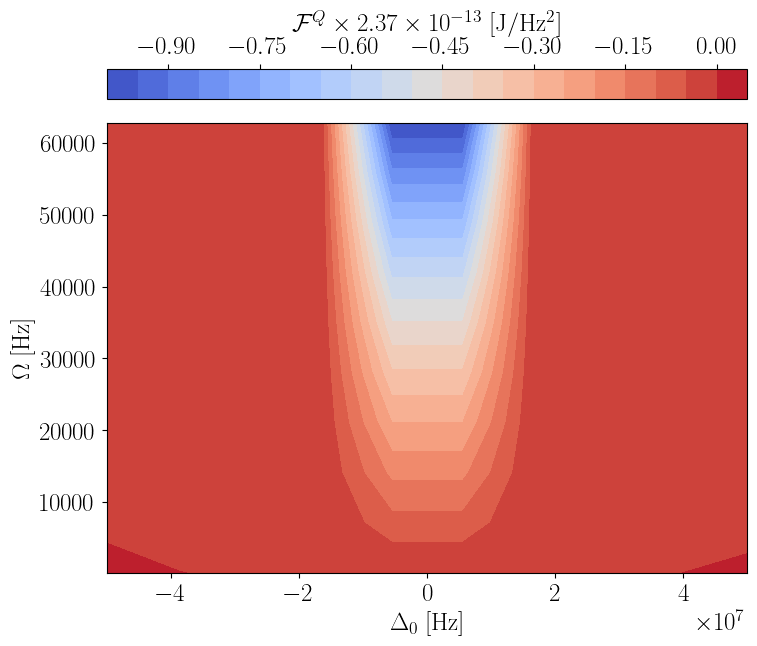

Computing Liouvillian Gap for 8x8 system...
Liouvillian gap between 8.80e-03 and 8.80e-03.


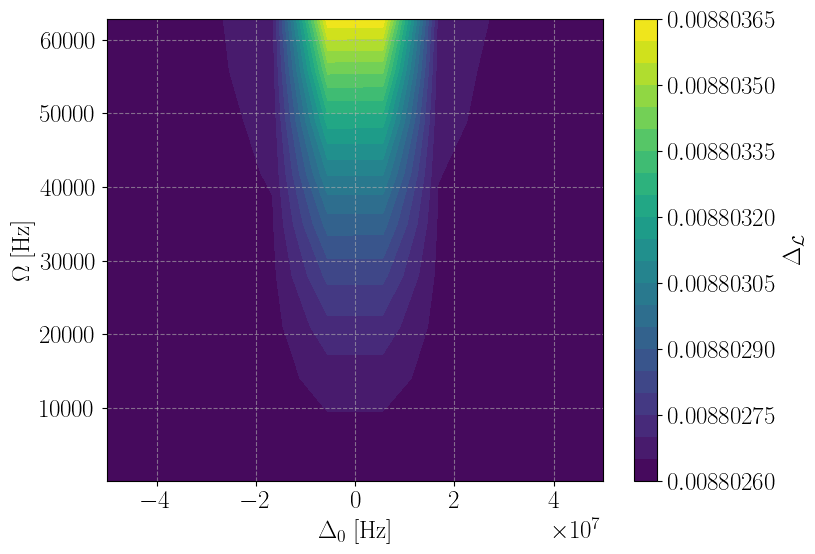

Starting cycle integration for d=8 system...
--- Results ---
Geometric Heat: 1007868.316892484
Dissipated Heat: 9126868.898060389
Net: 10134737.214952873
Temperature change over the cycle: 7.741147871254633347e-05 K


In [17]:
Delta0_range = [r'$\Delta_0$', -50 * 1e6, 50 * 1e6] # Hz
Omega_range = [r'$\Omega$', 2 * np.pi * 20, 2 * np.pi * 1e4] # Hz

p1_grid_mtls, p2_grid_mtls, curvature_mtls, max_val_mtls = old_heat_curvature(
    H_motion_tls, H_motion_tls_ref, diss_motion_tls,
    ranges=[Delta0_range, Omega_range],
    points=10
)

# Plot Heat Curvature
fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p1_grid_mtls, p2_grid_mtls, curvature_mtls, levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val_mtls:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal',
    label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/Hz^2]}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\Delta_0 \; \mathrm{[Hz]}$')
ax.set_ylabel(r'$\Omega \; \mathrm{[Hz]}$')
plt.savefig('motion_tls.pdf', bbox_inches='tight')
plt.show()

# Liouvillian Gap
liouvillian_gap(
    H_motion_tls,
    diss_motion_tls,
    params=[r'$\Delta_0 \; \mathrm{[Hz]}$', r'$\Omega \; \mathrm{[Hz]}$'],
    ranges=[Delta0_range,Omega_range],
    points=10
)

# Cycle heats
q_geo_mtls, q_diss_mtls = compute_cycle_heats(
    H_motion_tls,
    H_motion_tls_ref,
    diss_motion_tls,
    p_min=[Delta0_range[1], Omega_range[1]],
    p_max=[Delta0_range[2], Omega_range[2]],
    tau=2 * np.pi,
    points=100
)

kB = 1.380649e-23  # Boltzmann constant in J/K
hbar = 1.0545718e-34  # Reduced Planck constant in J*s
print("Temperature change over the cycle:", (q_geo_mtls + q_diss_mtls) * hbar / kB, "K")

## Example: Quantum Absorption Refrigerator ##


In [ ]:
def H_refrigerator(Delta, Omega):
    """
    Three-level quantum absorption refrigerator Hamiltonian.
    Delta: energy gap scale
    Omega: Rabi frequency
    """
    H = np.array([
        [0, 0, Omega / 2],
        [0, Delta / 2, Omega / 2],
        [Omega / 2, Omega / 2, Delta]
    ], dtype=complex)
    return H


def nBE(E, T):
    """Bose-Einstein distribution"""
    if T == 0:
        return 0.0
    if np.abs(E) < 1e-12:
        return 0.0
    return 1.0 / (np.exp(E / T) - 1.0)


def diss_refrigerator(r):
    """
    Three-bath dissipator for quantum absorption refrigerator.
    Three reservoirs: cold (Tc), work/driving (Tw), hot (Th)
    """
    def func(Delta, Omega):
        # Jump operators
        ColdDown = np.array([[0, 1, 0], [0, 0, 0], [0, 0, 0]], dtype=complex)
        ColdUp = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=complex)
        
        WorkDown = np.array([[0, 0, 0], [0, 0, 1], [0, 0, 0]], dtype=complex)
        WorkUp = np.array([[0, 0, 0], [0, 0, 0], [0, 1, 0]], dtype=complex)
        
        HotDown = np.array([[0, 0, 1], [0, 0, 0], [0, 0, 0]], dtype=complex)
        HotUp = np.array([[0, 0, 0], [0, 0, 0], [1, 0, 0]], dtype=complex)
        
        # Thermal occupation numbers
        Tc, Tw, Th = 1.0, 2.0, 2.0  # Temperature ratios
        nc = nBE(Delta / 2, Tc)
        nw = nBE(Delta / 2, Tw)
        nh = nBE(Delta, Th)
        
        # Dissipation rates
        gamma = 2 * np.pi * 6.1  # decay rate
        
        # Cold reservoir dissipator
        diss_cold = gamma * (nc + 1) * lindblad_dissipator(ColdDown, r) + \
                    gamma * nc * lindblad_dissipator(ColdUp, r)
        
        # Work/driving reservoir dissipator
        diss_work = gamma * (nw + 1) * lindblad_dissipator(WorkDown, r) + \
                    gamma * nw * lindblad_dissipator(WorkUp, r)
        
        # Hot reservoir dissipator
        diss_hot = gamma * (nh + 1) * lindblad_dissipator(HotDown, r) + \
                   gamma * nh * lindblad_dissipator(HotUp, r)
        
        return diss_cold + diss_work + diss_hot
    
    return func


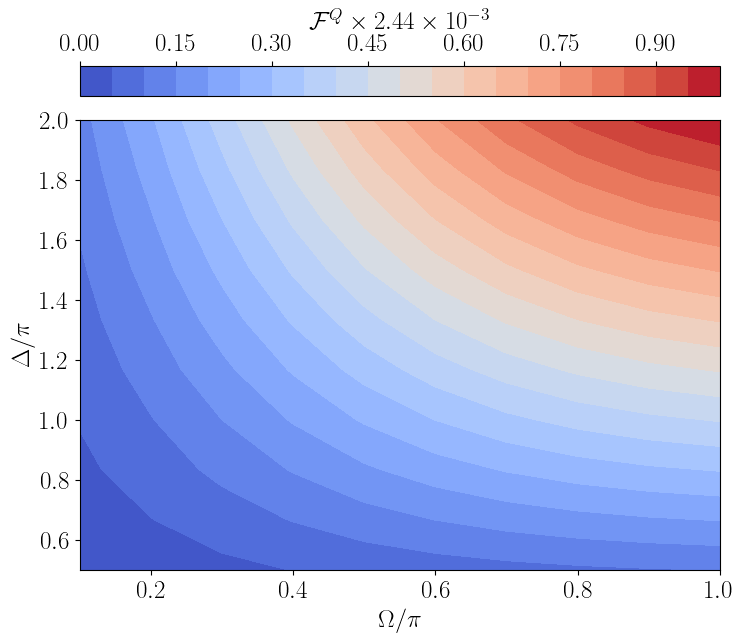

Computing Liouvillian Gap for 3x3 system...
Liouvillian gap between 2.68e+01 and 1.03e+02.


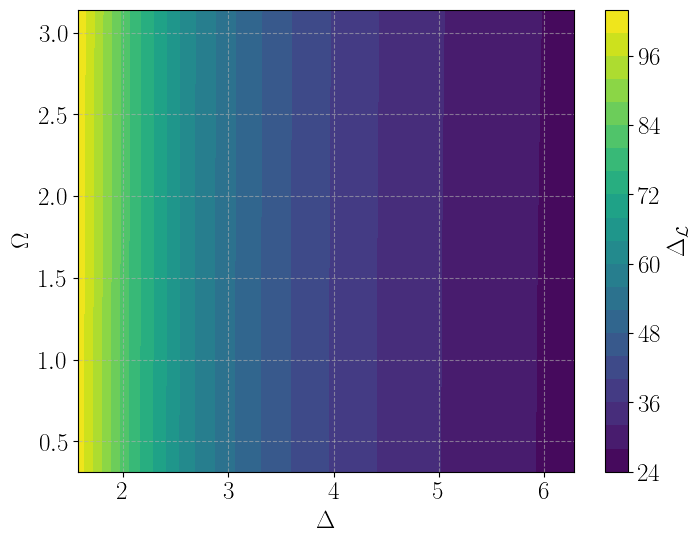

(array([1.57079633, 2.0943951 , 2.61799388, 3.14159265, 3.66519143,
        4.1887902 , 4.71238898, 5.23598776, 5.75958653, 6.28318531]),
 array([0.31415927, 0.62831853, 0.9424778 , 1.25663706, 1.57079633,
        1.88495559, 2.19911486, 2.51327412, 2.82743339, 3.14159265]),
 array([[102.57411575,  78.09947875,  61.17577516,  50.3132369 ,
          42.89193107,  37.60039651,  33.70927904,  30.78077767,
          28.53651876,  26.7914269 ],
        [102.59785073,  78.10883309,  61.18307896,  50.31976387,
          42.89807662,  37.60632714,  33.71507717,  30.7864881 ,
          28.54216718,  26.79702845],
        [102.63752191,  78.12427836,  61.19523272,  50.3306352 ,
          42.90831572,  37.61620952,  33.72473949,  30.79600471,
          28.55158074,  26.80636405],
        [102.69329483,  78.14559697,  61.21220761,  50.34584043,
          42.92264318,  37.63004067,  33.73826417,  30.80932634,
          28.56475869,  26.81943325],
        [102.76539235,  78.17248696,  61.23396336,  

In [ ]:
# Quantum Absorption Refrigerator Analysis
Delta_range = [r'$\Delta$', 0.5 * np.pi, 2 * np.pi]  # Energy scale
Omega_range_ref = [r'$\Omega$', 0.1 * np.pi, np.pi]  # Rabi frequency

p1_grid_ref, p2_grid_ref, curvature_ref, max_val_ref = old_heat_curvature(
    H_refrigerator, H_refrigerator, diss_refrigerator,
    ranges=[Delta_range, Omega_range_ref],
    points=10
)

# Plot Heat Curvature
fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p2_grid_ref / np.pi, p1_grid_ref / np.pi, curvature_ref, levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val_ref:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal',
    label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\Omega / \pi$')
ax.set_ylabel(r'$\Delta / \pi$')
plt.savefig('refrigerator_curvature.pdf', bbox_inches='tight')
plt.show()

# Liouvillian Gap for refrigerator
liouvillian_gap(
    H_refrigerator,
    diss_refrigerator,
    params=[r'$\Delta$', r'$\Omega$'],
    ranges=[Delta_range, Omega_range_ref],
    points=10
)